# Noise estimation for real-data tomography

**Problem.** The phantom study (`rd_phantom_analysis.py`, `procedure=True`) fixes `reg_param = 1e-1`, but on real shots the reconstructions only look right with `reg_param ≈ 1`. The two pipelines are numerically consistent — the culprit is the noise estimate. `estimate_noise_std` (wavelet, finest-scale MAD on the *spatial* profile) captures only the additive noise **floor** of the diagnostic. The real per-channel noise is strongly **signal-dependent** (photon statistics + calibration errors ∝ signal), so the likelihood weight $1/(2\sigma^2)$ vastly over-trusts the bright core channels, and one has to crank up `reg_param` to compensate.

**Fix implemented here.** The `*_finetimegrid.mat` files (0.1 ms sampling) give a direct, per-channel measurement of the noise via frame-to-frame differences. Pooling all such shots, the noise follows an affine law
$$\sigma_{ch} = a + b\,|y_{ch}|,$$
which is a property of the SXR diagnostic and therefore transfers to shots *without* a fine time grid (e.g. 85270). `_DataFidelityFunctional` natively supports this heteroscedastic model via `sigma_err=[a, b]`, and the CV anisotropy tuning rebuilds folds from `f.sigma_err`, so the whole pipeline works unchanged — with `reg_param` kept at the phantom-study value `1e-1`.

This notebook reproduces the figures of `experimental_data_analysis.ipynb` (up to the fluctuation-analysis section) with the calibrated noise model.

In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import scipy.io as scio
import skimage.transform as skimt
from scipy import ndimage

import reaction_diffusion.routines.tomo_fusion.hyperparameter_tuning as hyper_tune
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

from helpers import *

device: cuda


/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisCoherenceEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisEdgeEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:CurvaturePreservingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: Contributio

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
H, W = 120, 40
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

missing keys: 0
unexpected keys: 0


In [4]:
def preprocess_magnetic_data(data_exp, Nz, Nr, doublet=False):
    # interpolate original equilibria on the prescribed inversion grid
    eqs = np.zeros((data_exp["psi"].shape[2], Nz, Nr))
    rs = data_exp['liuqe_rs'][:, 0]
    zs = data_exp['liuqe_zs'][:, 0]
    dr_liuqe = np.mean(np.diff(rs.flatten()))
    dz_liuqe = np.mean(np.diff(zs.flatten()))
    tcv_zmin, tcv_zmax = -0.75, 0.75
    tcv_rmin, tcv_rmax = 0.624, 1.1376
    dz, dr = (tcv_zmax - tcv_zmin) / Nz, (tcv_rmax - tcv_rmin) / Nr
    tcv_Zs = np.linspace(tcv_zmin, tcv_zmax, Nz + 1, endpoint=True)[:-1] + dz / 2
    tcv_Rs = np.linspace(tcv_rmin, tcv_rmax, Nr + 1, endpoint=True)[:-1] + dr / 2
    for i in range(data_exp['psi'].shape[2]):
        # convert inversion grid coordinates to image coordinates
        r_pos_evals = (tcv_Rs - rs.min()) / dr_liuqe
        z_pos_evals = -(np.flip(tcv_Zs) - zs.max()) / dz_liuqe
        coord_eval_pos = np.zeros((2, Nz * Nr))
        for nz in range(Nz):
            for nr in range(Nr):
                coord_eval_pos[0, nr + nz * Nr] = z_pos_evals[nz]
                coord_eval_pos[1, nr + nz * Nr] = r_pos_evals[nr]
        if doublet:
            # for doublet, flip the original equilibrium to match the new grid orientation
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i], axis=0),
                                                   coord_eval_pos, order=2, mode="nearest",
                                                   prefilter=True).reshape(Nz, Nr)
        else:
            # evaluate original fbte input on the prescribed inversion grid
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i].T, axis=0),
                                                   coord_eval_pos, order=2, mode="nearest",
                                                   prefilter=True).reshape(Nz, Nr)
    return eqs

In [5]:
import os

# select samples to be used for normalization procedure
samples_idxs = np.arange(0, 10000)
train_samples_path = Path(f"../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = torch.from_numpy(np.array(train_samples_normalization, dtype=np.float32)).to(device)

# load forward model
A_path = Path("forward_model/forward_model_sxr_full_geometry.npy")
A_sparse = np.load(A_path).astype(np.float32)
A_max = A_sparse.max()  # capture ORIGINAL max BEFORE normalization (used to rescale physical y_tomo)
A_sparse /= A_max  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)

# compute y_tomo distribution
y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T

0.0 1.0 (100, 4800)


## 1. Calibrating the diagnostic noise model

The shots with a fine time grid (0.1 ms sampling) allow a direct, per-channel noise measurement: frame-to-frame differences remove the (slowly evolving) signal, and `std(diff)/√2` is the noise std of each channel. We compare this "ground-truth" noise level with what the wavelet spatial estimator reports, and fit the affine noise model $\sigma_{ch} = a + b\,|y_{ch}|$ (in the same normalized-`A` units used by the inversion).

In [6]:
finetime_shots = [88764, 88767, 88772, 88794, 88798, 88997]

sig_ch_all, y_ch_all, rows = [], [], []
for s in finetime_shots:
    d = scio.loadmat(f"experimental_data/shot_data_{s}_finetimegrid.mat")["data"][0, 0]
    good_s = d["good_channels"].flatten() - 1
    # measurements in the normalized-A units used for the inversion
    m = d["measurements"] * d["etendues"].flatten()[None, :] * 4 * np.pi / A_max
    sig_t = np.std(np.diff(m, axis=0), axis=0) / np.sqrt(2)  # temporal noise std, per channel
    y_mean = np.abs(m).mean(axis=0)
    sig_ch_all.append(sig_t[good_s])
    y_ch_all.append(y_mean[good_s])

    # what the wavelet estimator says on a single spatial profile of the same shot
    dc = scio.loadmat(f"experimental_data/shot_data_{s}.mat")["data"][0, 0]
    good_c = dc["good_channels"].flatten() - 1
    y_prof = (np.array(dc["measurements"][14, :]) * dc["etendues"].flatten() * 4 * np.pi / A_max)[good_c]
    rows.append((s, float(estimate_noise_std(y_prof)), float(np.median(sig_t[good_s]))))

sig_ch_all = np.concatenate(sig_ch_all)
y_ch_all = np.concatenate(y_ch_all)

# calibrated affine noise model: sigma_ch = a_abs + b_rel * |y_ch| (absolute normalized-A units)
M = np.vstack([np.ones_like(y_ch_all), y_ch_all]).T
(a_abs, b_rel), *_ = np.linalg.lstsq(M, sig_ch_all, rcond=None)
r2 = 1 - np.var(sig_ch_all - M @ np.array([a_abs, b_rel])) / np.var(sig_ch_all)
print(f"calibrated noise model: sigma = {a_abs:.3e} + {b_rel:.4f} * |y|   (R^2 = {r2:.2f})\n")

print(f"{'shot':>8} | {'wavelet (spatial)':>18} | {'temporal (median)':>18} | {'temporal/wavelet':>16}")
for s, sw, st in rows:
    print(f"{s:>8} | {sw:>18.3e} | {st:>18.3e} | {st / sw:>16.2f}")

calibrated noise model: sigma = 4.105e+08 + 0.0370 * |y|   (R^2 = 0.73)

    shot |  wavelet (spatial) |  temporal (median) | temporal/wavelet
   88764 |          7.275e+08 |          7.337e+08 |             1.01
   88767 |          1.040e+09 |          6.187e+08 |             0.59
   88772 |          5.323e+08 |          6.945e+08 |             1.30
   88794 |          2.013e+08 |          6.863e+08 |             3.41
   88798 |          6.588e+08 |          7.202e+08 |             1.09
   88997 |          5.565e+08 |          7.019e+08 |             1.26


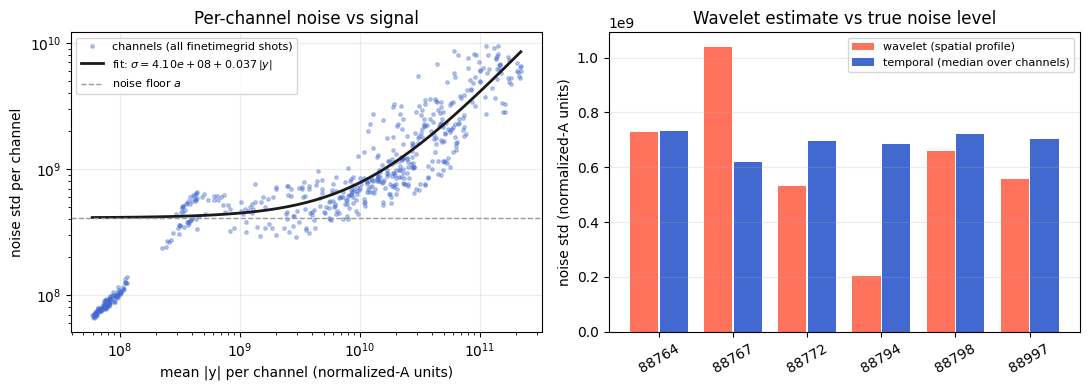

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# per-channel noise vs signal level: the noise is strongly signal-dependent
ax = axes[0]
ax.loglog(y_ch_all, sig_ch_all, ".", color="#4269d0", alpha=0.35, markersize=5,
          label="channels (all finetimegrid shots)")
yy = np.logspace(np.log10(y_ch_all.min()), np.log10(y_ch_all.max()), 100)
ax.loglog(yy, a_abs + b_rel * yy, "-", color="#1a1a1a", linewidth=2,
          label=fr"fit: $\sigma = {a_abs:.2e} + {b_rel:.3f}\,|y|$")
ax.axhline(a_abs, color="#9498a0", linewidth=1, linestyle="--", label="noise floor $a$")
ax.set_xlabel("mean |y| per channel (normalized-A units)")
ax.set_ylabel("noise std per channel")
ax.set_title("Per-channel noise vs signal")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# wavelet estimate on a single spatial profile vs true (temporal) noise level
ax = axes[1]
xs = np.arange(len(rows))
ax.bar(xs - 0.2, [r[1] for r in rows], width=0.38, color="#ff725c", label="wavelet (spatial profile)")
ax.bar(xs + 0.2, [r[2] for r in rows], width=0.38, color="#4269d0", label="temporal (median over channels)")
ax.set_xticks(xs)
ax.set_xticklabels([str(r[0]) for r in rows], rotation=30)
ax.set_ylabel("noise std (normalized-A units)")
ax.set_title("Wavelet estimate vs true noise level")
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

**Takeaways.** (i) The wavelet spatial estimate is unreliable — it disagrees with the true (temporal) noise by up to ~3× in either direction, and even when it agrees it only measures the noise *floor*. (ii) The per-channel noise grows with signal (relative component $b \approx 4\%$): for bright core channels the true σ is several times the floor. The affine model $[a, b]$ is a **diagnostic property** (consistent across shots), so we can apply it to any shot.

In the inversion the data is rescaled as $y/\alpha$, so the model becomes `sigma_err = [a_abs / alpha, b_rel]` — exactly the two-parameter form `_DataFidelityFunctional` supports (it builds $\sigma_i = \mathtt{sigma\_err}[0] + \mathtt{sigma\_err}[1]\, y_i$ and whitens the geometry matrix accordingly). The CV anisotropy tuning rebuilds each fold from `f.sigma_err`, so hyperparameter tuning is unchanged.

## 2. Shot data

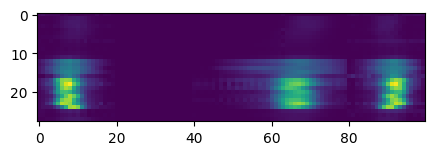

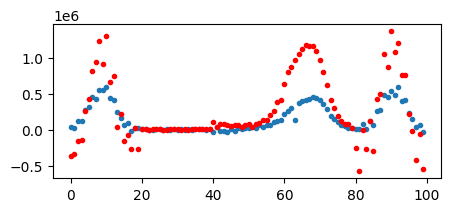

In [8]:
# shot number
shots = [85270, 88458, 88794, 88764, 88772, 88767, 88798, 88997]
shot = shots[0]  # 85270

exp_data = scio.loadmat(f'experimental_data/shot_data_{shot}.mat')['data'][0, 0]  # singlet
psi = preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=False)

plt.figure(figsize=(5, 2))
plt.imshow(np.abs(exp_data["measurements"]))
plt.show()
plt.figure(figsize=(5, 2))
plt.plot(exp_data["measurements"][10, :], '.')
plt.plot(exp_data["measurements"][26, :], 'r.')
plt.show()

## 3. MAP + diffPIR reconstructions with the calibrated noise model

Same pipeline as `experimental_data_analysis.ipynb` (CV tuning of the anisotropy parameter, positivity constraint, TCV mask), but the data-fidelity term uses the calibrated per-channel noise $\sigma_i = a/\alpha + b\, y_i$. **`reg_param` stays at the phantom-study value `1e-1`.**

In [ ]:
# define tomographic data
exp_idxs = np.array([8, 12, 16, 20, 24])
exp_idxs = exp_idxs[exp_idxs < exp_data["measurements"].shape[0]]  # ensure selected indices are within bounds

im_maps = []
recon_info = []

# define grid of anisotropic parameters for tuning
anis_params_grid = np.logspace(-4, 0, 13)

tcv_mask = np.load("reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask > 0] = 1

reg_param = 1e-1   # from the phantom study (rd_phantom_analysis.py, procedure=True)
anis_param = 1e-2  # initial value, tuned by CV below
with_positivity_constraint = True

good_channels = exp_data['good_channels'].flatten() - 1
bool_good_channels = np.zeros(y_tomo_train.shape[1], dtype=bool)
bool_good_channels[good_channels] = True
A_good_csr = sp.csr_matrix(A_tomo.cpu().numpy())[good_channels, :]

posterior_tomo = torch.zeros((len(exp_idxs), 100, 1, H, W), dtype=torch.float32, device=device)

for idx, exp_idx in enumerate(exp_idxs):

    y_tomo = np.array(exp_data["measurements"][exp_idx, :] * exp_data["etendues"].flatten() * 4 * np.pi) / A_max
    y_tomo = y_tomo[good_channels]  # remove faulty channels

    # amplitude normalization towards the training distribution
    alpha, y_closest = compute_normalization_coefficient(
        torch.from_numpy(y_tomo.reshape(1, -1)).to(device=device, dtype=torch.float32),
        y_tomo_train[:, bool_good_channels],
    )
    y_tomo_rescaled = y_tomo / alpha

    # ------------------------------------------------------------------
    # Noise model
    # ------------------------------------------------------------------
    # old scalar estimate (captures only the noise floor) -- for reference
    sigma_wavelet = float(estimate_noise_std(y_tomo_rescaled))
    # calibrated signal-dependent model in the rescaled units: sigma_i = a/alpha + b * y_i
    sigma_err_model = np.array([a_abs / alpha, b_rel])
    sigma_vec = sigma_err_model[0] + sigma_err_model[1] * y_tomo_rescaled
    assert (sigma_vec > 0).all(), "affine noise model produced non-positive sigma"
    t_slice = exp_data['measurements_times'].flatten()[exp_idx]
    print(f"t = {t_slice:.3f}s | alpha = {alpha:.3e} | sigma_wavelet = {sigma_wavelet:.4f} | "
          f"calibrated sigma: floor {sigma_err_model[0]:.4f}, median {np.median(sigma_vec):.4f}, "
          f"max {sigma_vec.max():.4f}")

    # ------------------------------------------------------------------
    # Define functionals with noisy tomo data
    # ------------------------------------------------------------------
    f = fct_def._DataFidelityFunctional(
        dim_shape=(1, H, W),
        noisy_tomo_data=y_tomo_rescaled,
        sigma_err=float(np.sqrt(np.mean(sigma_vec ** 2))),
        geometry_matrix=A_good_csr,
    )
    g = AnisDiffusionOp(
        dim_shape=(1, H, W),
        alpha=anis_param,
        diff_method_struct_tens="fd",
        freezing_arr=psi[exp_idx],
        sampling=0.0125,
        matrix_based_impl=True,
    )

    # ------------------------------------------------------------------
    # Tune anisotropic parameter via CV (blind to ground truth)
    # ------------------------------------------------------------------
    anis_param_data = hyper_tune.anis_param_tuning(
        f, g,
        reg_param=reg_param,
        tuning_techniques=["CV_full"],
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=tcv_mask,
        cv_strategy=["random"],
        anis_params=anis_params_grid,
        plot=False,
    )
    best_anis_idx = np.argmin(anis_param_data["CV_full_random"][1, :])
    best_anis_param = anis_param_data["CV_full_random"][0, best_anis_idx]
    g = hyper_tune._redefine_anis_param_logprior(g, best_anis_param)

    # ------------------------------------------------------------------
    # MAP
    # ------------------------------------------------------------------
    im_map = bcomp.compute_MAP(
        f, g, reg_param,
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=tcv_mask,
        show_progress=False,
    ) * alpha

    x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)
    im_maps.append(x_map)

    # per-channel-weighted residual: chi ~ 1 means the fit is consistent with the noise model
    resid = A_good_csr @ (im_map.ravel() / alpha) - y_tomo_rescaled
    chi = float(np.sqrt(np.mean((resid / sigma_vec) ** 2)))
    recon_info.append(dict(exp_idx=int(exp_idx), t=float(t_slice), alpha=float(alpha),
                           sigma_wavelet=sigma_wavelet, best_anis_param=float(best_anis_param), chi=chi))
    print(f"   best_anis_param = {best_anis_param:.3e} | weighted residual chi = {chi:.2f}")

    # ------------------------------------------------------------------
    # diffPIR posterior sampling (scalar noise level: rms of the per-channel sigmas)
    # ------------------------------------------------------------------
    sigma_y_diffpir = float(np.sqrt(np.mean(sigma_vec ** 2)))
    posterior_tomo[idx], tomo_residuals, diffusion_process = sample_posterior_diffpir(
        model=model,
        schedule=schedule,
        A=A_tomo[bool_good_channels, :],
        y=torch.from_numpy(y_tomo_rescaled).to(device=device, dtype=torch.float32),
        image_shape=(1, H, W),
        num_samples=100,
        num_inference_steps=250,
        zeta=0.8,
        sigma_y=sigma_y_diffpir,
        lambda_=100,   # 300 for normalize_data=False
        clip_range=None,
    )

t = 0.540s | alpha = 3.775e+08 | sigma_wavelet = 0.2276 | calibrated sigma: floor 1.0874, median 1.1148, max 1.6083
Tuning regularization parameter: 5-fold cross validation (`CV_full`)



/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


   best_anis_param = 1.000e-03 | weighted residual chi = 0.43


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

t = 0.780s | alpha = 6.769e+09 | sigma_wavelet = 0.0225 | calibrated sigma: floor 0.0606, median 0.1163, max 0.6165
Tuning regularization parameter: 5-fold cross validation (`CV_full`)



...

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

t = 1.500s | alpha = 1.340e+10 | sigma_wavelet = 0.0260 | calibrated sigma: floor 0.0306, median 0.0400, max 0.5550
Tuning regularization parameter: 5-fold cross validation (`CV_full`)



/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


   best_anis_param = 1.000e-02 | weighted residual chi = 1.36


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

In [28]:
a_abs/1e8

np.float64(4.104752694423739)

In [29]:
sigma_err_model[0]

np.float64(0.030643616507376917)

In [30]:
float(np.sqrt(np.mean(sigma_vec ** 2)))

0.15259849364526282

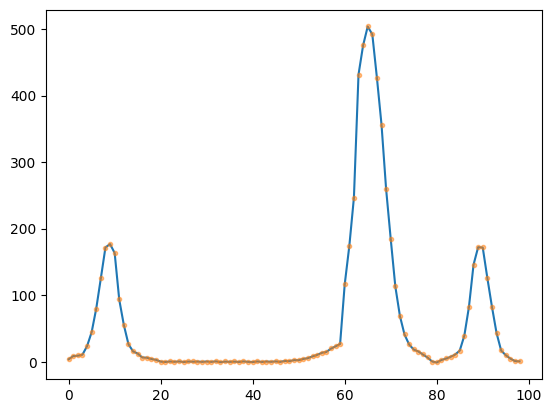

In [31]:
plt.plot(y_tomo/3.77e8)
plt.plot(y_tomo/3.77e8 + np.random.normal(0, 1.184/5, size=y_tomo.shape), '.', alpha=0.5)

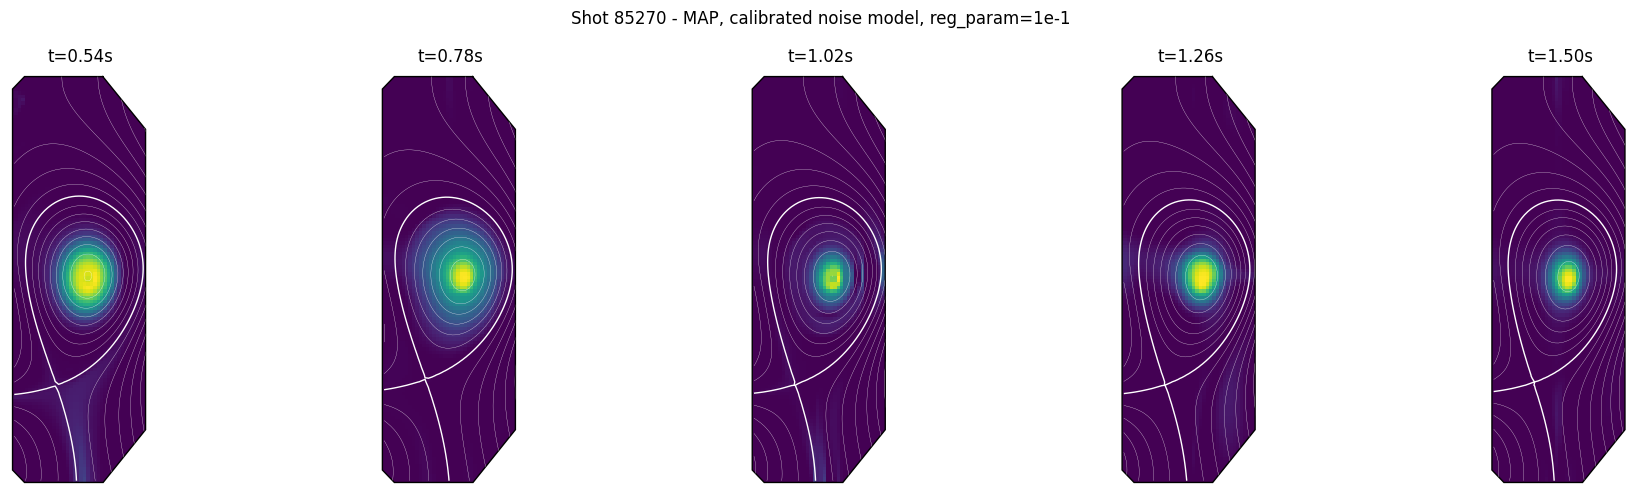

In [32]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------

psi_slice = psi[exp_idx]

summary = torch.stack([
    x_map_[0, 0].cpu() for x_map_ in im_maps
])
summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs))])
show_samples(
    summary,
    titles=["t={:.2f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs],
    title="Shot {} - MAP, calibrated noise model, reg_param=1e-1".format(shot),
    ncols=len(im_maps),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs],
    colorbar=False,
)

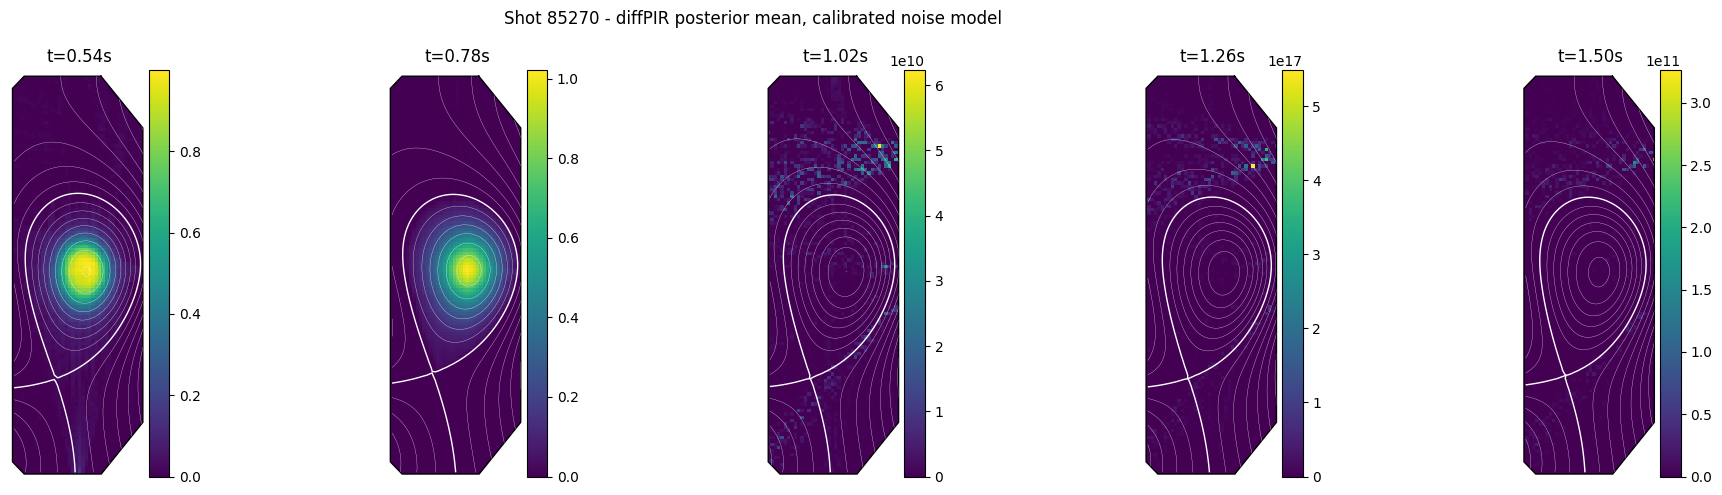

In [33]:
# show diffpir posterior means (rescaled units)

post_mean = posterior_tomo.mean(dim=1)
summary = torch.stack([post_mean[i, 0].cpu() for i in range(len(exp_idxs))])

show_samples(
    summary,
    titles=["t={:.2f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs],
    title="Shot {} - diffPIR posterior mean, calibrated noise model".format(shot),
    ncols=len(exp_idxs),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs],
    colorbar=True,
    vmin=0,
)

## 4. Validation: does the calibrated noise model replace the manual `reg_param` fix?

For one time slice we compare three configurations, each with its own CV anisotropy tuning:

1. wavelet $\hat\sigma$ + `reg_param=0.1` — the old default that produced over-fitted, artifact-ridden maps;
2. wavelet $\hat\sigma$ + `reg_param=1` — the manual workaround;
3. calibrated $\sigma(y)$ + `reg_param=0.1` — the fix, keeping the phantom-study value.

The weighted residual $\chi$ is always evaluated against the calibrated noise model (our best estimate of the truth): $\chi \ll 1$ means fitting noise, $\chi \approx 1$ a statistically consistent fit.

Tuning regularization parameter: 5-fold cross validation (`CV_full`)



/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


wavelet $\hat\sigma$, reg=0.1 (old default): best_anis = 1.00e-01 | weighted chi = 1.11
Tuning regularization parameter: 5-fold cross validation (`CV_full`)



/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


wavelet $\hat\sigma$, reg=1 (manual fix): best_anis = 2.15e-04 | weighted chi = 1.24
Tuning regularization parameter: 5-fold cross validation (`CV_full`)



/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


calibrated $\sigma(y)$, reg=0.1 (this fix): best_anis = 4.64e-04 | weighted chi = 0.94


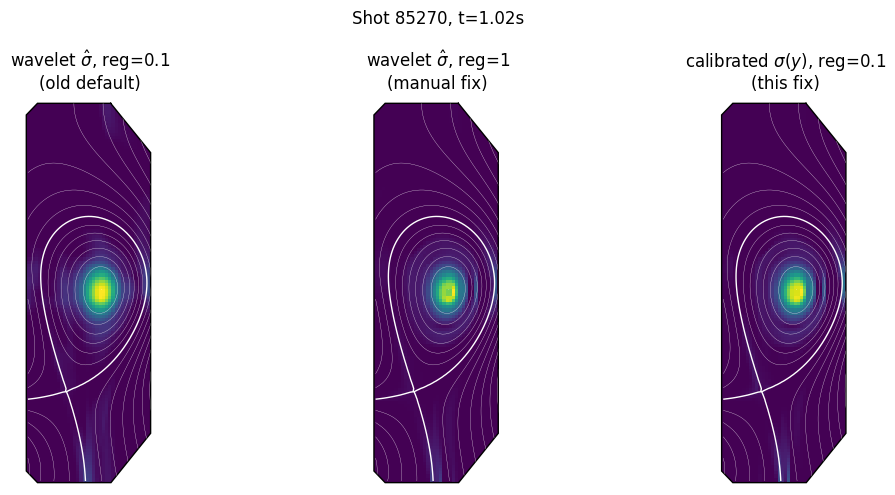

In [16]:
exp_idx_cmp = 16

y_tomo = np.array(exp_data["measurements"][exp_idx_cmp, :] * exp_data["etendues"].flatten() * 4 * np.pi) / A_max
y_tomo = y_tomo[good_channels]
alpha_cmp, _ = compute_normalization_coefficient(
    torch.from_numpy(y_tomo.reshape(1, -1)).to(device=device, dtype=torch.float32),
    y_tomo_train[:, bool_good_channels],
)
y_tomo_rescaled = y_tomo / alpha_cmp
sigma_wavelet = float(estimate_noise_std(y_tomo_rescaled))
sigma_err_model = np.array([a_abs / alpha_cmp, b_rel])
sigma_vec = sigma_err_model[0] + sigma_err_model[1] * y_tomo_rescaled

configs = [
    ("wavelet $\\hat\\sigma$, reg=0.1\n(old default)", sigma_wavelet, 1e-1),
    ("wavelet $\\hat\\sigma$, reg=1\n(manual fix)", sigma_wavelet, 1.0),
    ("calibrated $\\sigma(y)$, reg=0.1\n(this fix)", sigma_err_model, 1e-1),
]

maps_cmp = []
for name, sig, rp in configs:
    f = fct_def._DataFidelityFunctional(
        dim_shape=(1, H, W),
        noisy_tomo_data=y_tomo_rescaled,
        sigma_err=sig,
        geometry_matrix=A_good_csr,
    )
    g = AnisDiffusionOp(
        dim_shape=(1, H, W),
        alpha=anis_param,
        diff_method_struct_tens="fd",
        freezing_arr=psi[exp_idx_cmp],
        sampling=0.0125,
        matrix_based_impl=True,
    )
    anis_param_data = hyper_tune.anis_param_tuning(
        f, g,
        reg_param=rp,
        tuning_techniques=["CV_full"],
        with_pos_constraint=True,
        clipping_mask=tcv_mask,
        cv_strategy=["random"],
        anis_params=anis_params_grid,
        plot=False,
    )
    best = anis_param_data["CV_full_random"][0, np.argmin(anis_param_data["CV_full_random"][1, :])]
    g = hyper_tune._redefine_anis_param_logprior(g, best)
    im = bcomp.compute_MAP(f, g, rp, with_pos_constraint=True, clipping_mask=tcv_mask, show_progress=False)
    resid = A_good_csr @ im.ravel() - y_tomo_rescaled
    chi = float(np.sqrt(np.mean((resid / sigma_vec) ** 2)))
    maps_cmp.append(np.asarray(im).reshape(H, W) * alpha_cmp)
    label = name.replace(chr(10), ' ')
    print(f"{label}: best_anis = {best:.2e} | weighted chi = {chi:.2f}")

summary = torch.stack([torch.from_numpy(m).float() for m in maps_cmp])
show_samples(
    summary,
    titles=[c[0] for c in configs],
    title="Shot {}, t={:.2f}s".format(shot, exp_data['measurements_times'].flatten()[exp_idx_cmp]),
    ncols=3,
    figsize=(12, 5),
    contour_images=[psi[exp_idx_cmp]] * 3,
    colorbar=False,
)

**Conclusion.** With the calibrated signal-dependent noise model the phantom-study `reg_param = 1e-1` produces reconstructions on par with the manual `reg_param = 1` workaround — the apparent inconsistency was an under-estimated (and mis-shaped) noise level, not a wrong regularization parameter. For any new shot, only `[a_abs, b_rel]` (a diagnostic property) and the per-shot normalization `alpha` are needed; no fine-time-grid data is required at inversion time.